In [1]:
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

CLASS_NAMES = [
    'HM', 'LQS', 'QHS', 'MS',
    'A1_SU-35', 'A2_C-130', 'A3_C-17', 'A4_C-5',
    'A5_F-16', 'A6_TU-160', 'A7_E-3', 'A8_B-52',
    'A9_P-3C', 'A10_B-1B', 'A11_E-8', 'A12_TU-22',
    'A13_F-15', 'A14_KC-135', 'A15_F-22', 'A16_FA-18',
    'A17_TU-95', 'A18_KC-10', 'A19_SU-34', 'A20_SU-24',
    'FSC',
]

DATASETS = {
    'basic_dataset':      Path('../../data/generated/basic_dataset/labels'),
    'mar20_20class':      Path('../../data/generated/mar20_20class/labels'),
    'shiprsimage_4class': Path('../../data/generated/shiprsimage_4class/labels'),
}

In [2]:
def count_classes(labels_dir):
    c = Counter()
    for f in labels_dir.rglob('*.txt'):
        for line in f.read_text().splitlines():
            if line.strip():
                c[int(line.split()[0])] += 1
    return c

counters = {name: count_classes(path) for name, path in DATASETS.items()}

rows = []
for i, cls in enumerate(CLASS_NAMES):
    basic  = counters['basic_dataset'].get(i, 0)
    mar20  = counters['mar20_20class'].get(i, 0)
    shiprs = counters['shiprsimage_4class'].get(i, 0)
    total  = basic + mar20 + shiprs
    rows.append({'class_id': i, 'name': cls, 'basic': basic, 'mar20': mar20, 'shiprs': shiprs, 'total': total})

df = pd.DataFrame(rows).set_index('class_id')
print(f"Всего объектов: {df['total'].sum():,}")
df

Всего объектов: 30,022


,name,basic,mar20,shiprs,total
class_id,,,,,
0,HM,16,0,121,137
1,LQS,28,0,437,465
2,QHS,609,0,1302,1911
3,MS,1889,0,2922,4811
4,A1_SU-35,1317,325,0,1642
5,A2_C-130,1297,432,0,1729
6,A3_C-17,998,171,0,1169
7,A4_C-5,500,142,0,642
8,A5_F-16,1017,245,0,1262


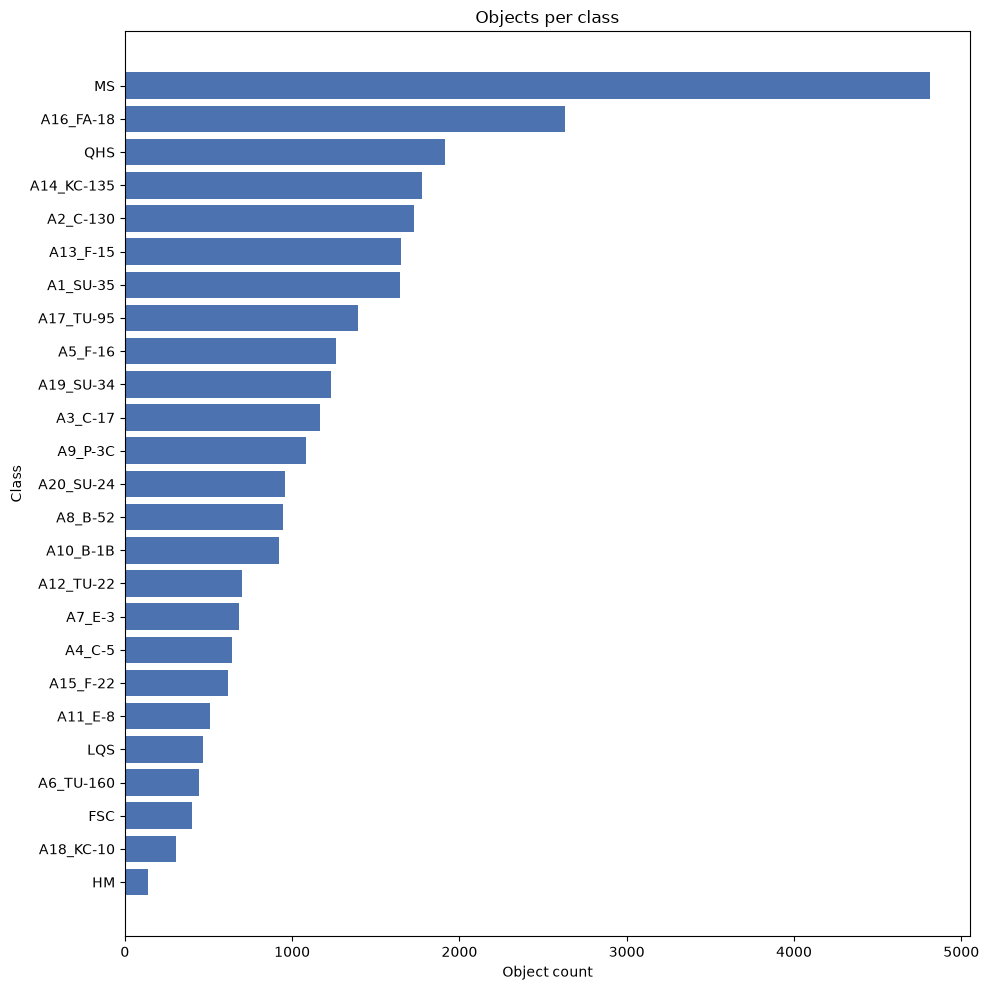

In [3]:
df_sorted = df.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(df_sorted['name'], df_sorted['total'], color='#4C72B0')
ax.set_xlabel('Object count')
ax.set_ylabel('Class')
ax.set_title('Objects per class')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [4]:
RARE_THRESHOLD = 500
rare = df[df['total'] < RARE_THRESHOLD].sort_values('total')

print(f'Rare class (total < {RARE_THRESHOLD}):')
print(rare[['name', 'basic', 'mar20', 'shiprs', 'total']].to_string())
print()
print('Сколько нужно сгенерировать copy-paste для выравнивания до порога:')
for _, row in rare.iterrows():
    needed = RARE_THRESHOLD - int(row['total'])
    print(f"  {row['name']:<14}: now {int(row['total']):>4}  ->  need +{needed}")

Rare class (total < 500):
               name  basic  mar20  shiprs  total
class_id                                        
0                HM     16      0     121    137
21        A18_KC-10    262     46       0    308
24              FSC    400      0       0    400
9         A6_TU-160    361     80       0    441
1               LQS     28      0     437    465

Сколько нужно сгенерировать copy-paste для выравнивания до порога:
  HM            : now  137  ->  need +363
  A18_KC-10     : now  308  ->  need +192
  FSC           : now  400  ->  need +100
  A6_TU-160     : now  441  ->  need +59
  LQS           : now  465  ->  need +35
